In [2]:
!pip install pandas
!pip install boto3


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Import dependencies
import boto3
import os
import pandas as pd


### 1. LOAD DATA INTO AWS S3

In [4]:
import boto3
import os

# Define variables
bucket_name   = 'finrisk-amdari'
folder_data   = './finrisk_data'
target_folder = 'finrisk/raw'  # removed leading slash - not needed in S3

# activate a boto3 client
s3 = boto3.client('s3')

# loop into data folder and upload to s3
for filename in os.listdir(folder_data):     # loop into data folder
    if filename.endswith('.csv'):            #check for files that end with .csv
        filepath = os.path.join(folder_data, filename) # define filepath
        s3_key = target_folder + '/' + filename        
        
        s3.upload_file(
            Filename = filepath,     # use the client method (upload file) to upload all csv files to s3 
            Bucket   = bucket_name,
            Key      = s3_key        # combination of the path in s3 and the filename
        )
        print(f'Uploaded {filename} to s3 successfully')

### 2. LOAD DATA FROM AWS S3 TO POSTGRES


In [5]:
# create a client
s3 = boto3.client('s3')
# define parameters
bucket = 'finrisk-amdari'
prefix = 'finrisk/raw/'
files  = [
    'transaction_data.csv',
    'customer_profiles.csv',
    'credit_bureau_data.csv',
    'credit_applications.csv'
]
# loop into the list of files and download them
for file in files:
    s3.download_file(bucket, prefix + file, file)
    print(f'Downloaded {file} successfully')

Downloaded transaction_data.csv successfully
Downloaded customer_profiles.csv successfully
Downloaded credit_bureau_data.csv successfully
Downloaded credit_applications.csv successfully


### 3. LOADING DATA ROM AWS S3 TO POSTGRES DATABASE

In [6]:
import os
!pip install sqlalchemy psycopg2-binary

from sqlalchemy import create_engine, text

# define a function with a postgres client
def get_db_engine():
    db_url = (
        "postgresql://avnadmin:AVNS_S2FcH-IWsTsEmztTc9Y@"
        "pg-demo9-olawalelateef9-feb1.c.aivencloud.com:15980/defaultdb"
    )
    return create_engine(db_url)

             


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
def upload_data():
    try:
        engine = get_db_engine()

        table_files = {
            "customer_profiles": r"C:\Users\User\Desktop\FINRISK_AMDARI\finrisk_data\processed\customer_profiles.csv",
            "credit_applications": r"C:\Users\User\Desktop\FINRISK_AMDARI\finrisk_data\processed\credit_applications.csv",
            "transaction_data": r"C:\Users\User\Desktop\FINRISK_AMDARI\finrisk_data\processed\transaction_data.csv",
            "credit_bureau_data": r"C:\Users\User\Desktop\FINRISK_AMDARI\finrisk_data\processed\credit_bureau_data.csv"
        }

        # correct order for foreign keys
        upload_order = ["customer_profiles", "credit_applications", "transaction_data", "credit_bureau_data"]

        with engine.begin() as connection:  # ensures COMMIT
            for table in upload_order:
                file_path = table_files[table]

                if not os.path.exists(file_path):
                    print(f"Missing CSV for {table}: {file_path}")
                    continue

                result = connection.execute(text(f"SELECT COUNT(*) FROM {table}"))
                count = result.scalar()

                if count > 0:
                    print(f"`{table}` already has {count} rows. Skipping.")
                    continue

                df = pd.read_csv(file_path)
                if df.empty:
                    print(f"CSV for {table} is empty. Skipping.")
                    continue

                df.to_sql(
                    table,
                    connection,
                    if_exists="append",
                    index=False,
                    chunksize=1000,
                    method="multi"
                )
                print(f"Uploaded {len(df)} rows into `{table}`.")

        print("Upload finished.")

    except Exception as e:   
        print(f"Upload failed: {e}")


#  Call the function
upload_data()


`customer_profiles` already has 25000 rows. Skipping.
`credit_applications` already has 100000 rows. Skipping.
`transaction_data` already has 100000 rows. Skipping.
`credit_bureau_data` already has 25000 rows. Skipping.
Upload finished.


### 4. READING DATA FROM THE DATABASE

In [8]:
# Import libraries 

import os
import pandas as pd
from sqlalchemy import create_engine, text

# Create a function for postgres connection
def get_db_engine():
    db_url = (
        "postgresql://avnadmin:AVNS_S2FcH-IWsTsEmztTc9Y@"
        "pg-demo9-olawalelateef9-feb1.c.aivencloud.com:15980/defaultdb"
    )
    return create_engine(db_url)

# Instantiate the function
engine = get_db_engine()

# Define queries for each table
transaction_query   = 'SELECT * FROM transaction_data'
credit_app_query    = 'SELECT * FROM credit_applications'
customer_pro_query  = 'SELECT * FROM customer_profiles'
credit_bureau_query = 'SELECT * FROM credit_bureau_data'

# Load these data into pandas dataframes
transaction_df   = pd.read_sql(transaction_query, engine)
credit_app_df    = pd.read_sql(credit_app_query, engine)
customer_pro_df  = pd.read_sql(customer_pro_query, engine)
credit_bureau_df = pd.read_sql(credit_bureau_query, engine)

print("Data loaded successfully!")
print(f"Transactions: {len(transaction_df)} rows")
print(f"Credit Applications: {len(credit_app_df)} rows")
print(f"Customer Profiles: {len(customer_pro_df)} rows")
print(f"Credit Bureau Data: {len(credit_bureau_df)} rows")


Data loaded successfully!
Transactions: 100000 rows
Credit Applications: 100000 rows
Customer Profiles: 25000 rows
Credit Bureau Data: 25000 rows


### DATA CLEANING

#### Identifying missing values

In [11]:
transaction_df.head(5)
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   transaction_id        100000 non-null  object        
 1   customer_id           100000 non-null  object        
 2   transaction_date      100000 non-null  datetime64[ns]
 3   amount                100000 non-null  float64       
 4   merchant_category     100000 non-null  object        
 5   transaction_type      100000 non-null  object        
 6   location              100000 non-null  object        
 7   device_info           100000 non-null  object        
 8   fraud_flag            100000 non-null  int64         
 9   investigation_status  100000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(7)
memory usage: 7.6+ MB


In [12]:
credit_app_df.head(5)
credit_app_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   application_id        100000 non-null  object 
 1   customer_id           100000 non-null  object 
 2   application_date      100000 non-null  object 
 3   loan_amount           100000 non-null  float64
 4   loan_purpose          100000 non-null  object 
 5   employment_status     100000 non-null  object 
 6   annual_income         100000 non-null  float64
 7   debt_to_income_ratio  100000 non-null  float64
 8   credit_score          100000 non-null  int64  
 9   application_status    100000 non-null  object 
 10  default_flag          100000 non-null  int64  
dtypes: float64(3), int64(2), object(6)
memory usage: 8.4+ MB


In [14]:
customer_pro_df.head(5)
customer_pro_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         25000 non-null  object 
 1   customer_age        25000 non-null  int64  
 2   annual_income       25000 non-null  float64
 3   employment_status   25000 non-null  object 
 4   account_tenure      25000 non-null  int64  
 5   product_holdings    25000 non-null  int64  
 6   relationship_value  25000 non-null  float64
 7   risk_segment        25000 non-null  object 
 8   behavioral_score    25000 non-null  float64
 9   credit_score        25000 non-null  int64  
 10  city                25000 non-null  object 
 11  last_activity_date  25000 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 2.3+ MB


In [17]:
credit_bureau_df.head(5)
credit_bureau_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            25000 non-null  object 
 1   credit_score           25000 non-null  int64  
 2   credit_history_length  25000 non-null  int64  
 3   number_of_accounts     25000 non-null  int64  
 4   total_credit_limit     25000 non-null  float64
 5   credit_utilization     25000 non-null  float64
 6   payment_history        25000 non-null  object 
 7   public_records         25000 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 1.5+ MB


In [19]:
# missing values in trnsaction_df
transaction_df.isnull().sum()

transaction_id          0
customer_id             0
transaction_date        0
amount                  0
merchant_category       0
transaction_type        0
location                0
device_info             0
fraud_flag              0
investigation_status    0
dtype: int64

In [20]:
# missing values in customer_pro_df
customer_pro_df.isnull().sum()

customer_id           0
customer_age          0
annual_income         0
employment_status     0
account_tenure        0
product_holdings      0
relationship_value    0
risk_segment          0
behavioral_score      0
credit_score          0
city                  0
last_activity_date    0
dtype: int64

In [21]:
# missing values in credit_app_df
credit_app_df.isnull().sum()

application_id          0
customer_id             0
application_date        0
loan_amount             0
loan_purpose            0
employment_status       0
annual_income           0
debt_to_income_ratio    0
credit_score            0
application_status      0
default_flag            0
dtype: int64

In [22]:
# missing values in credit_bureau_df
credit_bureau_df.isnull().sum()

customer_id              0
credit_score             0
credit_history_length    0
number_of_accounts       0
total_credit_limit       0
credit_utilization       0
payment_history          0
public_records           0
dtype: int64

In [25]:
# Check for duplicates in transaction_df

duplicate_count_trans = transaction_df.duplicated().sum()
if duplicate_count > 0:
    print(f"Number of duplicate rows found: {duplicate_count}")
else:
    print("No duplicate rows found in the dataset")

No duplicate rows found in the dataset


In [27]:
# check for duplicates in customer_pro_df

duplicate_count_credit = credit_app_df.duplicated().sum()
if duplicate_count > 0:
    print(f"Number of duplicate rows found: {duplicate_count_credit}")
else:
    print("No duplicate rows found in the dataset")

No duplicate rows found in the dataset


In [28]:
# check for duplicates in customer_pro_df

duplicate_count_cb = credit_bureau_df.duplicated().sum()
if duplicate_count > 0:
    print(f"Number of duplicate rows found: {duplicate_count_cb}")
else:
    print("No duplicate rows found in the dataset")

No duplicate rows found in the dataset


In [31]:
# Convert date columns to datetime format
transaction_df['transaction_date']= pd.to_datetime(transaction_df['transaction_date'])
transaction_df.dtypes

transaction_id                  object
customer_id                     object
transaction_date        datetime64[ns]
amount                         float64
merchant_category               object
transaction_type                object
location                        object
device_info                     object
fraud_flag                       int64
investigation_status            object
dtype: object

In [32]:
credit_app_df['application_date']= pd.to_datetime(credit_app_df['application_date'])
credit_app_df.dtypes

application_id                  object
customer_id                     object
application_date        datetime64[ns]
loan_amount                    float64
loan_purpose                    object
employment_status               object
annual_income                  float64
debt_to_income_ratio           float64
credit_score                     int64
application_status              object
default_flag                     int64
dtype: object

In [33]:
customer_pro_df['last_activity_date']= pd.to_datetime(customer_pro_df['last_activity_date'])
customer_pro_df.dtypes

customer_id                   object
customer_age                   int64
annual_income                float64
employment_status             object
account_tenure                 int64
product_holdings               int64
relationship_value           float64
risk_segment                  object
behavioral_score             float64
credit_score                   int64
city                          object
last_activity_date    datetime64[ns]
dtype: object

In [37]:
# Check missing values
#def missing_report(df, name):
 #   miss = df.isna().sum().sort_values(ascending=False)
  #  print(f"\nMissing values in {name}:")
   # print(miss[miss > 0] if not miss.empty else "None")

#missing_report(transaction_df, "Transactions")
#missing_report(customer_pro_df, "Customers")
#missing_report(credit_app_df, "Applications")
#missing_report(credit_bureau_df, "Bureau")

# Check duplicates
#def duplicate_report(df, key, name):
 #   print(f"{name} duplicate {key}: {df.duplicated(subset=[key]).sum()}")

#duplicate_report(transaction_df, "transaction_id", "Transactions")
#duplicate_report(customer_pro_df, "customer_id", "Customers")
#duplicate_report(credit_app_df, "application_id", "Applications")
#duplicate_report(credit_bureau_df, "customer_id", "Bureau")

### EXPLORATORY DATA ANALYSIS (EDA)

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-11.3.0-cp311-cp311-win_amd64.whl.metadata (9.2 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.1 MB 9.4 MB/s eta 0:00:01
   ------------------ --------------------- 3.7/8.1 MB 9.1 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 8.6 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 7.9 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 7.3 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 5.7 MB/s eta 0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


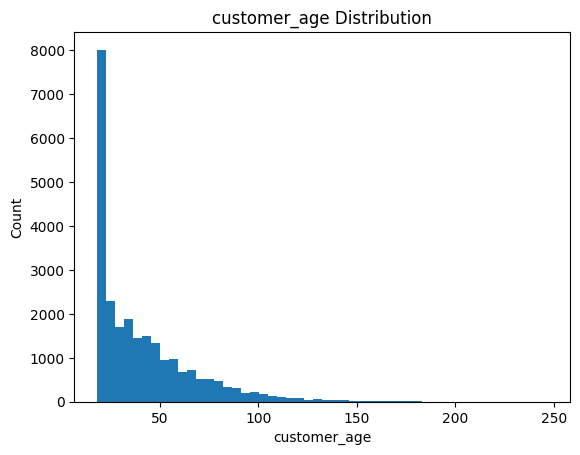

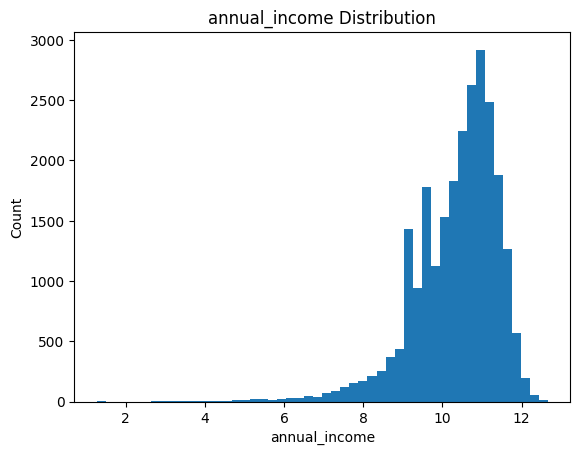

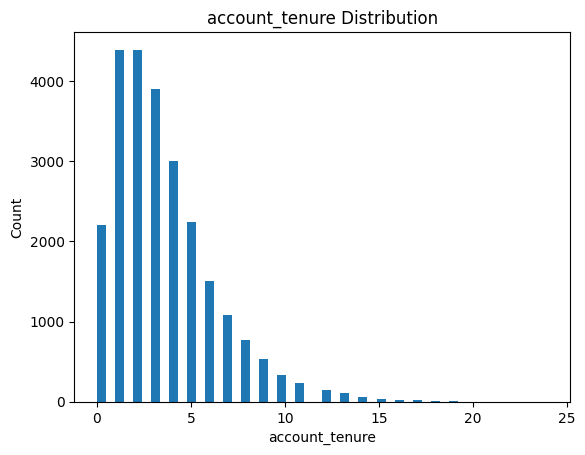

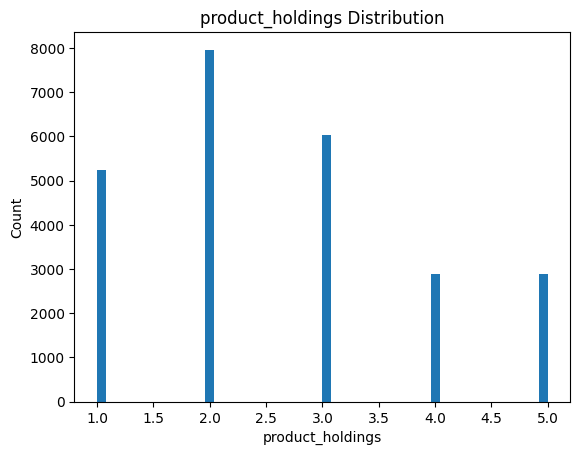

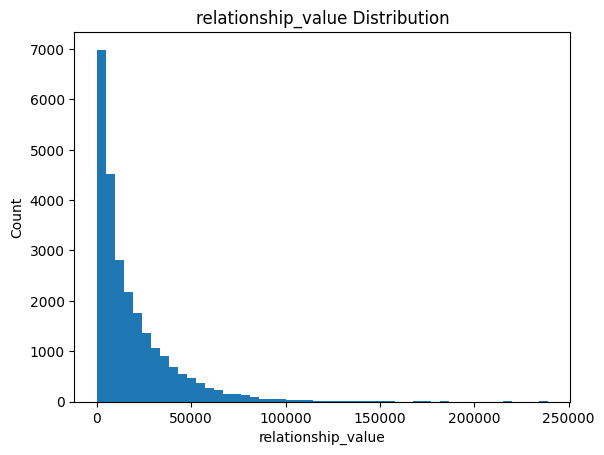

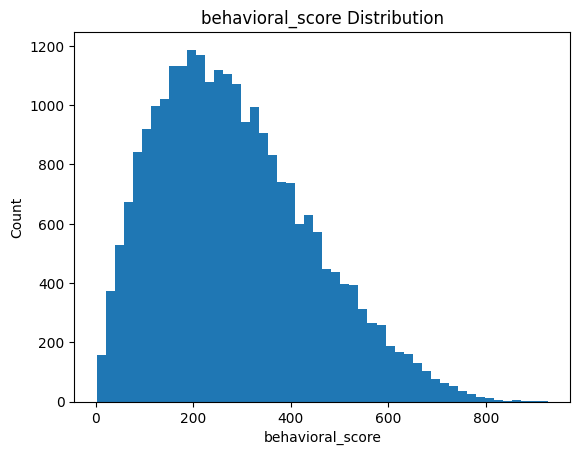

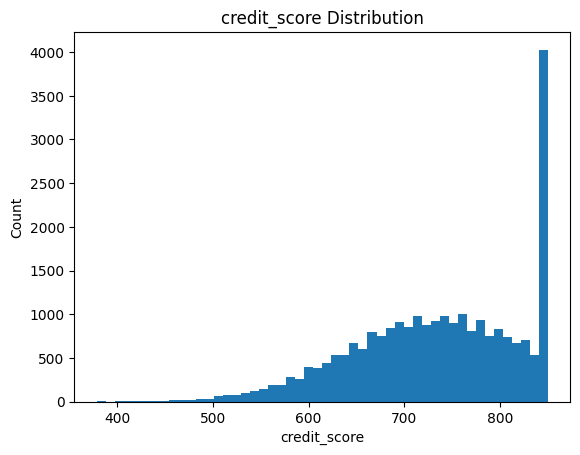

In [39]:
# Install required packages
!pip install matplotlib seaborn
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = ["customer_age", "annual_income", "account_tenure",
                "product_holdings", "relationship_value",
                "behavioral_score", "credit_score"]

for col in numeric_cols:
    plt.figure()
    data = customer_pro_df[col].dropna()
    plt.hist(np.log1p(data) if col=="annual_income" else data, bins=50)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


In [40]:
# Convert fraud_flag to numeric if needed
if transaction_df["fraud_flag"].dtype != bool:
    transaction_df["fraud_flag"] = transaction_df["fraud_flag"].map({1: True, 0: False})

fraud_rate = transaction_df["fraud_flag"].mean()
print(f"Overall fraud rate: {fraud_rate:.4f}")


Overall fraud rate: 0.0014


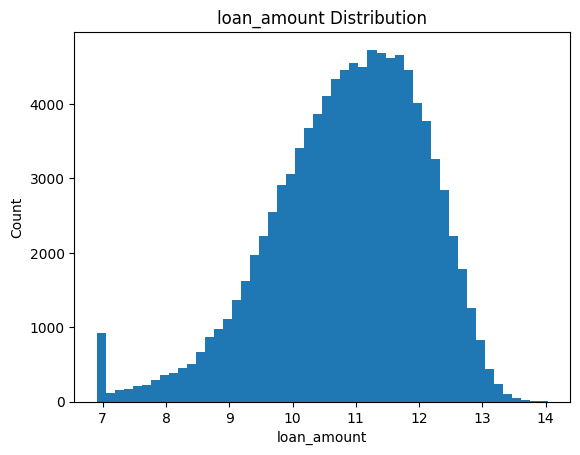

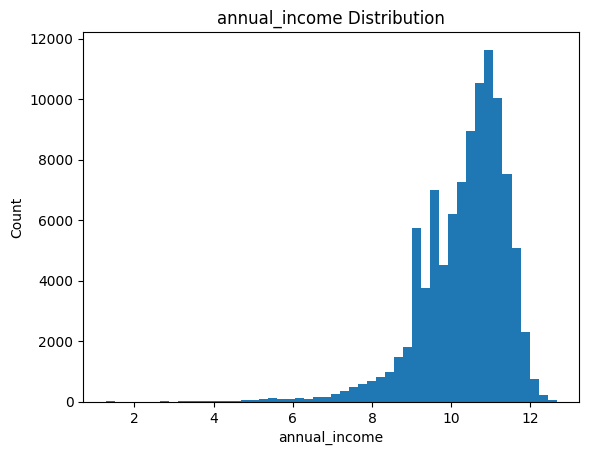

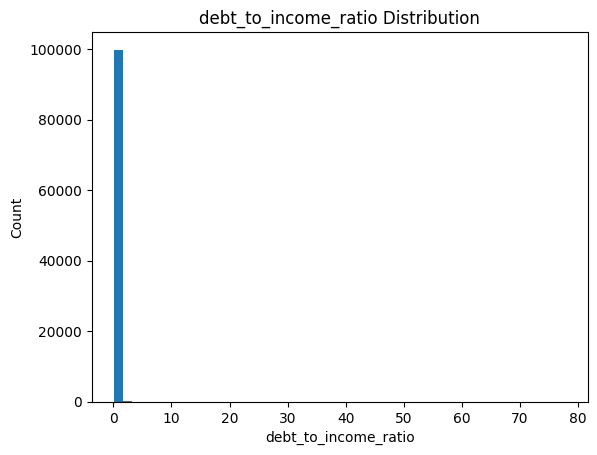

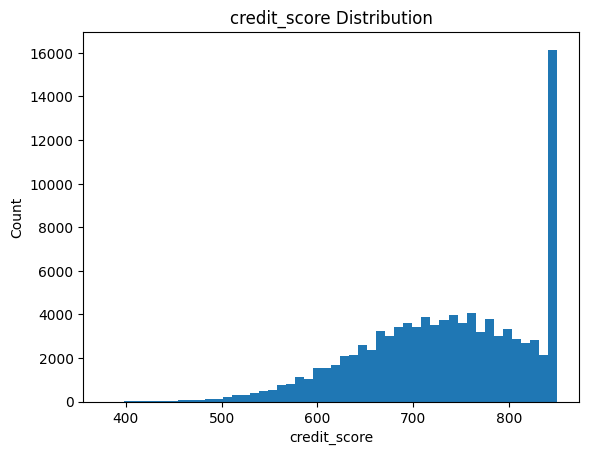

In [41]:
#credit applications(numerical)
numeric_cols_app = ["loan_amount", "annual_income", "debt_to_income_ratio", "credit_score"]

for col in numeric_cols_app:
    plt.figure()
    data = credit_app_df[col].dropna()
    plt.hist(np.log1p(data) if col in ["loan_amount","annual_income"] else data, bins=50)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


In [42]:
# default rate analysis
# Convert default_flag to boolean if needed
if credit_app_df["default_flag"].dtype != bool:
    credit_app_df["default_flag"] = credit_app_df["default_flag"].map({1: True, 0: False})

default_rate = credit_app_df["default_flag"].mean()
print(f"Overall default rate: {default_rate:.4f}")


Overall default rate: 0.0193


risk_segment
Subprime         0.001510
Prime            0.001424
Near-Prime       0.001331
Deep-Subprime    0.000844
Name: fraud_flag, dtype: float64


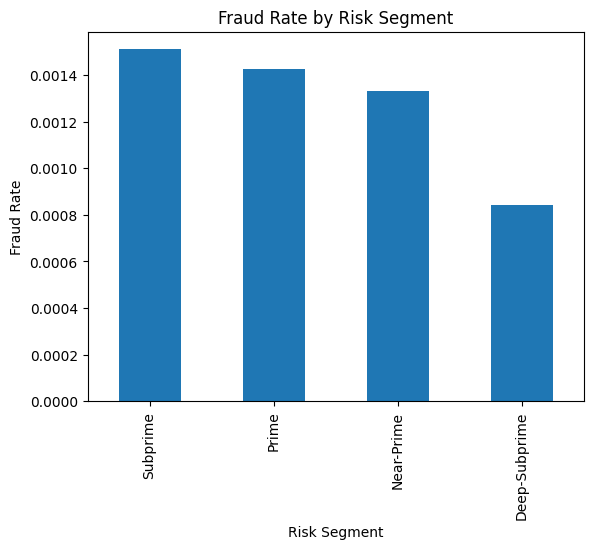

In [43]:
# Cross Table EDA: Fraud by Risk Segment
tx_cust_df = transaction_df.merge(customer_pro_df, on="customer_id", how="left")

fraud_by_segment = tx_cust_df.groupby("risk_segment")["fraud_flag"].mean().sort_values(ascending=False)
print(fraud_by_segment)

plt.figure()
fraud_by_segment.plot(kind="bar")
plt.title("Fraud Rate by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Fraud Rate")
plt.show()


loan_purpose
Debt Consolidation    0.022238
Business              0.020139
Home Purchase         0.019212
Home Improvement      0.019097
Personal              0.018379
Car Purchase          0.018028
Education             0.017887
Name: default_int, dtype: float64


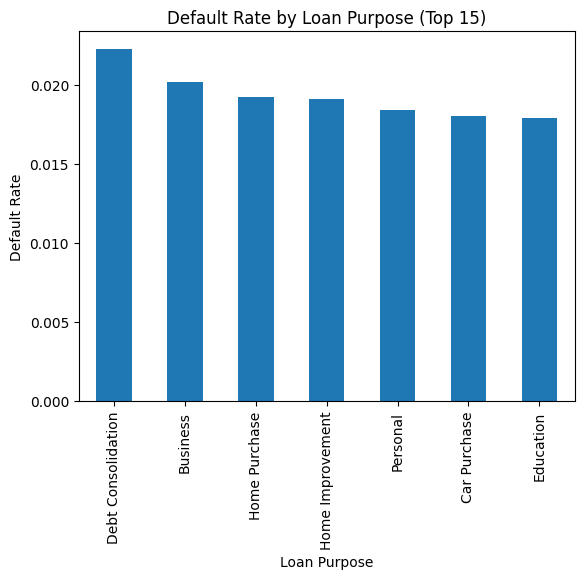

In [44]:
# Cross Table EDA: Default Rate by Loan Purpose
credit_app_df["default_int"] = credit_app_df["default_flag"].astype(int)

default_by_purpose = credit_app_df.groupby("loan_purpose")["default_int"].mean().sort_values(ascending=False)
print(default_by_purpose.head(15))

plt.figure()
default_by_purpose.head(15).plot(kind="bar")
plt.title("Default Rate by Loan Purpose (Top 15)")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate")
plt.show()


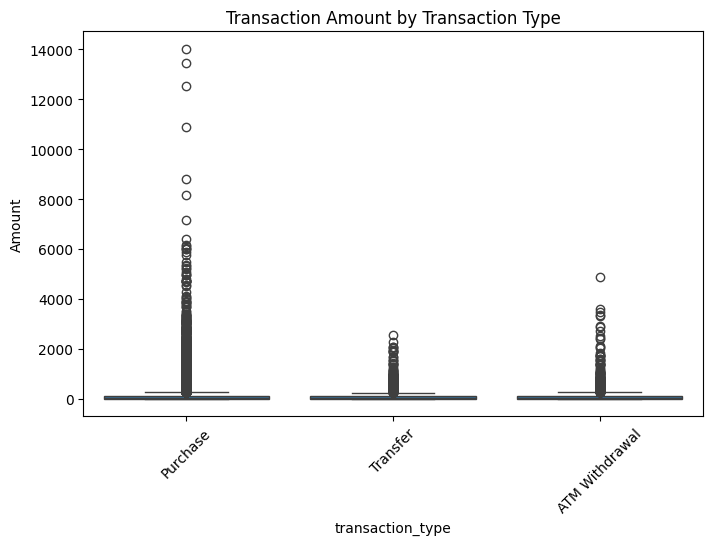

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(data=transaction_df, x="transaction_type", y="amount")
plt.title("Transaction Amount by Transaction Type")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()


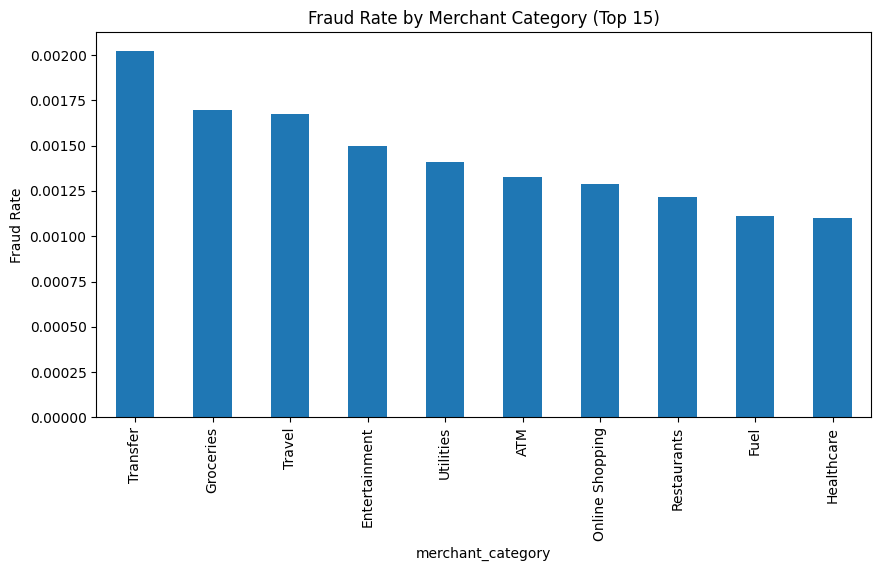

In [46]:
fraud_by_merchant = (
    transaction_df.groupby("merchant_category")["fraud_flag"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
fraud_by_merchant.head(15).plot(kind="bar")
plt.title("Fraud Rate by Merchant Category (Top 15)")
plt.ylabel("Fraud Rate")
plt.show()
